## 1. IMPORTACIONES Y CONFIGURACIÓN

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

print('Configuración completa')

Configuración completa


## 2. CARGA DE RESULTADOS DE TODOS LOS MODELOS

In [21]:
# Cargar resultados de cada modelo
resultados = {}

# Media Móvil y Holt-Winters
try:
    with open('resultados_ma_hw.pkl', 'rb') as f:
        resultados['MA_HW'] = pickle.load(f)
    print('Media Móvil y Holt-Winters cargados correctamente')
except FileNotFoundError:
    print('Advertencia: No se encontró resultados_ma_hw.pkl')
    resultados['MA_HW'] = None

# Tendencias Polinómicas
try:
    with open('resultados_tendencias.pkl', 'rb') as f:
        resultados['Tendencias'] = pickle.load(f)
    print('Tendencias Polinómicas cargadas correctamente')
except FileNotFoundError:
    print('Advertencia: No se encontró resultados_tendencias.pkl')
    resultados['Tendencias'] = None

# ARIMA
try:
    with open('resultados_ARIMA.pkl', 'rb') as f:
        resultados['ARIMA'] = pickle.load(f)
    print('ARIMA cargado correctamente')
except FileNotFoundError:
    print('Advertencia: No se encontró resultados_ARIMA.pkl')
    resultados['ARIMA'] = None

# Prophet
try:
    with open('resultados_Prophet.pkl', 'rb') as f:
        resultados['Prophet'] = pickle.load(f)
    print('Prophet cargado correctamente')
except FileNotFoundError:
    print('Advertencia: No se encontró resultados_Prophet.pkl')
    resultados['Prophet'] = None

# Datasets originales
try:
    with open('datasets_preparados.pkl', 'rb') as f:
        datasets = pickle.load(f)
    print('Datasets originales cargados correctamente')
except FileNotFoundError:
    print('Error: No se encontró datasets_preparados.pkl')
    datasets = None

print('\nCarga de resultados completada')
print(f"Modelos disponibles: {[k for k, v in resultados.items() if v is not None]}")

Media Móvil y Holt-Winters cargados correctamente
Tendencias Polinómicas cargadas correctamente
ARIMA cargado correctamente
Prophet cargado correctamente
Datasets originales cargados correctamente

Carga de resultados completada
Modelos disponibles: ['MA_HW', 'Tendencias', 'ARIMA', 'Prophet']


## 3. EXTRACCIÓN DE MÉTRICAS - PRODUCTO 1

In [22]:
# Extraer métricas de cada modelo para Producto 1
metricas_p1 = []

# Media Móvil
if resultados['MA_HW'] is not None:
    try:
        # Buscar el mejor modelo de media móvil
        mejor_ma_p1 = None
        mejor_rmse_ma = float('inf')
        
        for ventana, datos in resultados['MA_HW']['producto1']['media_movil'].items():
            if datos['rmse'] < mejor_rmse_ma:
                mejor_rmse_ma = datos['rmse']
                mejor_ma_p1 = ventana
        
        if mejor_ma_p1 is not None:
            metricas_p1.append({
                'Modelo': 'Media Móvil',
                'Configuración': f"Ventana={mejor_ma_p1}",
                'RMSE': mejor_rmse_ma,
                'Parámetros': f"n={mejor_ma_p1}"
            })
    except:
        pass

# Holt-Winters
if resultados['MA_HW'] is not None:
    try:
        hw_p1 = resultados['MA_HW']['producto1']['holt_winters']
        metricas_p1.append({
            'Modelo': 'Holt-Winters',
            'Configuración': f"HW Optimizado",
            'RMSE': hw_p1['best_rmse'],
            'Parámetros': f"α={hw_p1['best_params']['smoothing_level']:.3f}"
        })
    except:
        pass

# Tendencias Polinómicas
if resultados['Tendencias'] is not None:
    try:
        metricas_p1.append({
            'Modelo': 'Tendencia Polinómica',
            'Configuración': f"{resultados['Tendencias']['mejor_modelo_p1']}",
            'RMSE': resultados['Tendencias']['mejor_rmse_p1'],
            'Parámetros': f"grado={resultados['Tendencias']['mejor_grado_p1']}"
        })
    except:
        pass

# ARIMA
if resultados['ARIMA'] is not None:
    try:
        arima_p1 = resultados['ARIMA']['producto1']
        metricas_p1.append({
            'Modelo': 'ARIMA',
            'Configuración': f"ARIMA{arima_p1['best_order']}",
            'RMSE': arima_p1['rmse_rolling_opt'],
            'Parámetros': str(arima_p1['best_order'])
        })
    except:
        pass

# Prophet
if resultados['Prophet'] is not None:
    try:
        prophet_p1 = resultados['Prophet']['producto1']
        metricas_p1.append({
            'Modelo': 'Prophet',
            'Configuración': f"Prophet Optimizado",
            'RMSE': prophet_p1['metricas']['rmse_test'],
            'Parámetros': f"cp={prophet_p1['best_params']['changepoint_prior_scale']:.4f}"
        })
    except:
        pass

# Crear DataFrame
df_metricas_p1 = pd.DataFrame(metricas_p1)
df_metricas_p1 = df_metricas_p1.sort_values('RMSE')
df_metricas_p1['Ranking'] = range(1, len(df_metricas_p1) + 1)

print('='*70)
print('MÉTRICAS DE MODELOS - PRODUCTO 1')
print('='*70)
print(df_metricas_p1.to_string(index=False))
print('='*70)

mejor_modelo_p1 = df_metricas_p1.iloc[0]
print(f"\nMEJOR MODELO PRODUCTO 1: {mejor_modelo_p1['Modelo']}")
print(f"RMSE: {mejor_modelo_p1['RMSE']:.4f}")
print(f"Configuración: {mejor_modelo_p1['Configuración']}")

MÉTRICAS DE MODELOS - PRODUCTO 1
 Modelo      Configuración      RMSE Parámetros  Ranking
  ARIMA     ARIMA(6, 2, 7)  9.106204  (6, 2, 7)        1
Prophet Prophet Optimizado 24.466578  cp=0.4983        2

MEJOR MODELO PRODUCTO 1: ARIMA
RMSE: 9.1062
Configuración: ARIMA(6, 2, 7)


## 4. EXTRACCIÓN DE MÉTRICAS - PRODUCTO 2

In [23]:
# Extraer métricas de cada modelo para Producto 2
metricas_p2 = []

# Media Móvil
if resultados['MA_HW'] is not None:
    try:
        # Buscar el mejor modelo de media móvil
        mejor_ma_p2 = None
        mejor_rmse_ma = float('inf')
        
        for ventana, datos in resultados['MA_HW']['producto2']['media_movil'].items():
            if datos['rmse'] < mejor_rmse_ma:
                mejor_rmse_ma = datos['rmse']
                mejor_ma_p2 = ventana
        
        if mejor_ma_p2 is not None:
            metricas_p2.append({
                'Modelo': 'Media Móvil',
                'Configuración': f"Ventana={mejor_ma_p2}",
                'RMSE': mejor_rmse_ma,
                'Parámetros': f"n={mejor_ma_p2}"
            })
    except:
        pass

# Holt-Winters
if resultados['MA_HW'] is not None:
    try:
        hw_p2 = resultados['MA_HW']['producto2']['holt_winters']
        metricas_p2.append({
            'Modelo': 'Holt-Winters',
            'Configuración': f"HW Optimizado",
            'RMSE': hw_p2['best_rmse'],
            'Parámetros': f"α={hw_p2['best_params']['smoothing_level']:.3f}"
        })
    except:
        pass

# Tendencias Polinómicas
if resultados['Tendencias'] is not None:
    try:
        metricas_p2.append({
            'Modelo': 'Tendencia Polinómica',
            'Configuración': f"{resultados['Tendencias']['mejor_modelo_p2']}",
            'RMSE': resultados['Tendencias']['mejor_rmse_p2'],
            'Parámetros': f"grado={resultados['Tendencias']['mejor_grado_p2']}"
        })
    except:
        pass

# ARIMA
if resultados['ARIMA'] is not None:
    try:
        arima_p2 = resultados['ARIMA']['producto2']
        metricas_p2.append({
            'Modelo': 'ARIMA',
            'Configuración': f"ARIMA{arima_p2['best_order']}",
            'RMSE': arima_p2['rmse_rolling_opt'],
            'Parámetros': str(arima_p2['best_order'])
        })
    except:
        pass

# Crear DataFrame
df_metricas_p2 = pd.DataFrame(metricas_p2)
if len(df_metricas_p2) > 0:
    df_metricas_p2 = df_metricas_p2.sort_values('RMSE')
    df_metricas_p2['Ranking'] = range(1, len(df_metricas_p2) + 1)

    print('='*70)
    print('MÉTRICAS DE MODELOS - PRODUCTO 2')
    print('='*70)
    print(df_metricas_p2.to_string(index=False))
    print('='*70)

    mejor_modelo_p2 = df_metricas_p2.iloc[0]
    print(f"\nMEJOR MODELO PRODUCTO 2: {mejor_modelo_p2['Modelo']}")
    print(f"RMSE: {mejor_modelo_p2['RMSE']:.4f}")
    print(f"Configuración: {mejor_modelo_p2['Configuración']}")
else:
    print('No hay suficientes modelos para Producto 2')

MÉTRICAS DE MODELOS - PRODUCTO 2
Modelo  Configuración      RMSE Parámetros  Ranking
 ARIMA ARIMA(3, 1, 1) 12.598194  (3, 1, 1)        1

MEJOR MODELO PRODUCTO 2: ARIMA
RMSE: 12.5982
Configuración: ARIMA(3, 1, 1)


## 5. VISUALIZACIÓN COMPARATIVA - RMSE POR MODELO

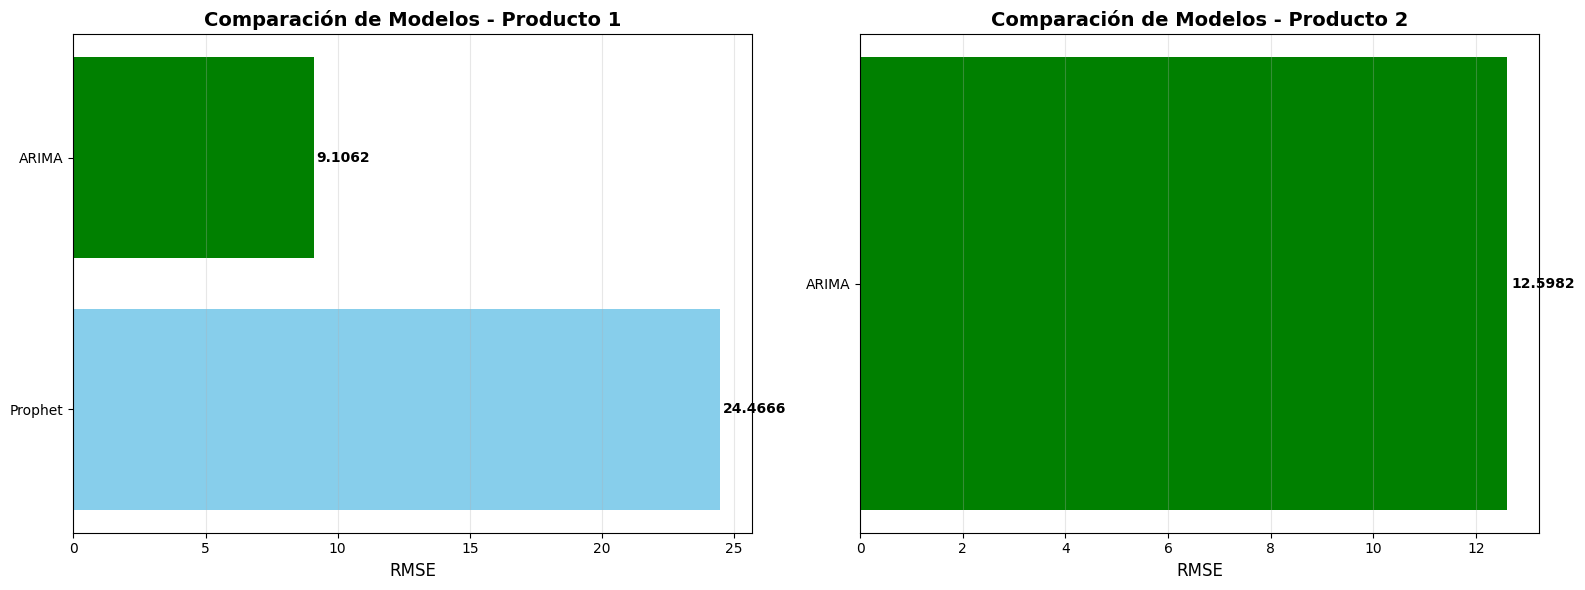

In [24]:
# Gráfico de barras comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Producto 1
colors_p1 = ['green' if i == 0 else 'skyblue' for i in range(len(df_metricas_p1))]
ax1.barh(df_metricas_p1['Modelo'], df_metricas_p1['RMSE'], color=colors_p1)
ax1.set_xlabel('RMSE', fontsize=12)
ax1.set_title('Comparación de Modelos - Producto 1', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# Añadir valores en las barras
for i, v in enumerate(df_metricas_p1['RMSE']):
    ax1.text(v + 0.1, i, f'{v:.4f}', va='center', fontweight='bold')

# Producto 2
if len(df_metricas_p2) > 0:
    colors_p2 = ['green' if i == 0 else 'lightcoral' for i in range(len(df_metricas_p2))]
    ax2.barh(df_metricas_p2['Modelo'], df_metricas_p2['RMSE'], color=colors_p2)
    ax2.set_xlabel('RMSE', fontsize=12)
    ax2.set_title('Comparación de Modelos - Producto 2', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    ax2.invert_yaxis()
    
    for i, v in enumerate(df_metricas_p2['RMSE']):
        ax2.text(v + 0.1, i, f'{v:.4f}', va='center', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Sin datos suficientes\npara Producto 2', 
             ha='center', va='center', fontsize=14, transform=ax2.transAxes)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 6. COMPARACIÓN VISUAL DE PRONÓSTICOS - PRODUCTO 1

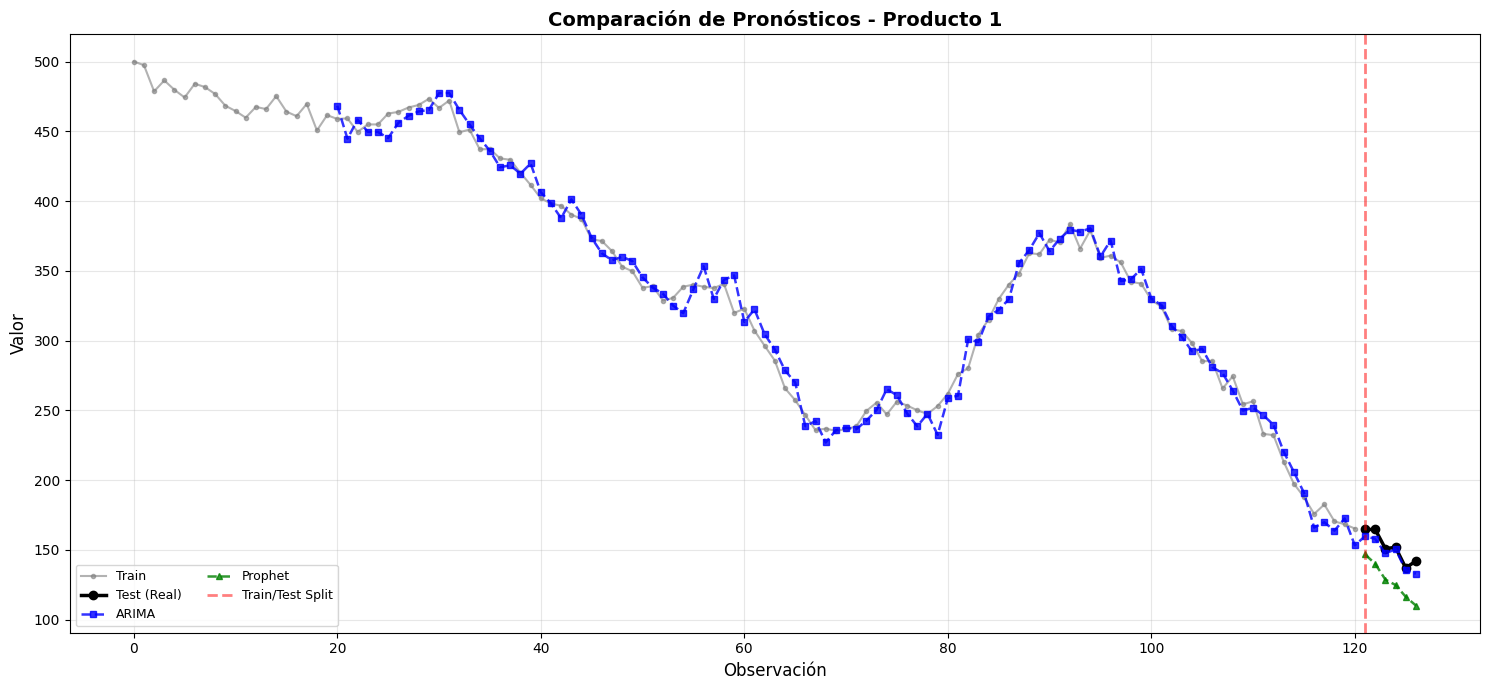

In [25]:
if datasets is not None:
    # Preparar datos
    data = datasets['data']
    test_to1 = datasets['test_to1']
    train_len = datasets['train_len']
    
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # Serie original
    ax.plot(data.index[:train_len], data['producto1'][:train_len], 
            'o-', label='Train', markersize=3, linewidth=1.5, alpha=0.6, color='gray')
    ax.plot(test_to1.index, test_to1['producto1'], 
            'o-', label='Test (Real)', markersize=6, linewidth=2.5, color='black')
    
    # Pronósticos de cada modelo
    colors = ['blue', 'green', 'orange', 'purple', 'red']
    markers = ['s', '^', 'D', 'v', 'p']
    idx_color = 0
    
    # Media Móvil
    if resultados['MA_HW'] is not None:
        try:
            mejor_ma = None
            mejor_rmse = float('inf')
            for ventana, datos in resultados['MA_HW']['producto1']['media_movil'].items():
                if datos['rmse'] < mejor_rmse:
                    mejor_rmse = datos['rmse']
                    mejor_ma = datos
            
            if mejor_ma is not None:
                pred_ma = mejor_ma['predicciones']
                indices_ma = mejor_ma['indices']
                ax.plot(indices_ma, pred_ma, 
                        f'{markers[idx_color]}--', label='Media Móvil', 
                        markersize=4, linewidth=1.8, alpha=0.8, color=colors[idx_color])
                idx_color += 1
        except:
            pass
    
    # Holt-Winters
    if resultados['MA_HW'] is not None:
        try:
            hw_p1 = resultados['MA_HW']['producto1']['holt_winters']
            pred_hw = hw_p1['predicciones']
            indices_hw = hw_p1['indices']
            ax.plot(indices_hw, pred_hw, 
                    f'{markers[idx_color]}--', label='Holt-Winters', 
                    markersize=4, linewidth=1.8, alpha=0.8, color=colors[idx_color])
            idx_color += 1
        except:
            pass
    
    # Tendencias Polinómicas
    if resultados['Tendencias'] is not None:
        try:
            tend_p1 = resultados['Tendencias']['producto1']
            pred_tend = tend_p1['predicciones_mejor']
            ax.plot(test_to1.index, pred_tend, 
                    f'{markers[idx_color]}--', label='Tendencia Polinómica', 
                    markersize=4, linewidth=1.8, alpha=0.8, color=colors[idx_color])
            idx_color += 1
        except:
            pass
    
    # ARIMA
    if resultados['ARIMA'] is not None:
        try:
            pred_arima = resultados['ARIMA']['producto1']['predicciones_rolling_opt']
            indices_arima = resultados['ARIMA']['producto1']['indices_prediccion_opt']
            ax.plot(indices_arima, pred_arima, 
                    f'{markers[idx_color]}--', label='ARIMA', 
                    markersize=4, linewidth=1.8, alpha=0.8, color=colors[idx_color])
            idx_color += 1
        except:
            pass
    
    # Prophet
    if resultados['Prophet'] is not None:
        try:
            pred_prophet = resultados['Prophet']['producto1']['predicciones_test']
            ax.plot(test_to1.index, pred_prophet, 
                    f'{markers[idx_color]}--', label='Prophet', 
                    markersize=4, linewidth=1.8, alpha=0.8, color=colors[idx_color])
            idx_color += 1
        except:
            pass
    
    ax.axvline(x=train_len, color='red', linestyle='--', 
               label='Train/Test Split', alpha=0.5, linewidth=2)
    
    ax.set_title('Comparación de Pronósticos - Producto 1', fontsize=14, fontweight='bold')
    ax.set_xlabel('Observación', fontsize=12)
    ax.set_ylabel('Valor', fontsize=12)
    ax.legend(loc='best', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No se pueden visualizar pronósticos sin datos originales')

## 7. ANÁLISIS DE ERRORES POR MODELO

## 6.5. COMPARACIÓN VISUAL DE PRONÓSTICOS - PRODUCTO 2

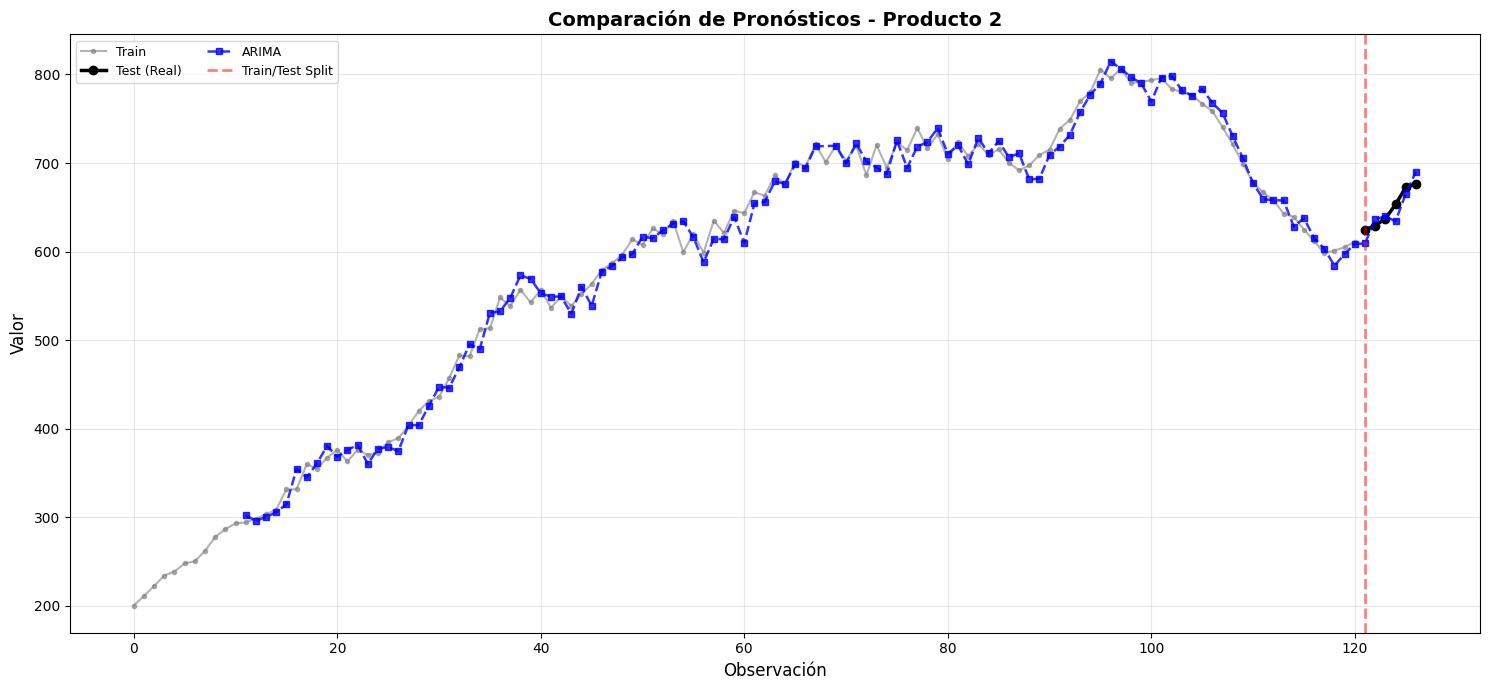

In [26]:
if datasets is not None and len(df_metricas_p2) > 0:
    # Preparar datos
    data = datasets['data']
    test_to2 = datasets['test_to2']
    train_len = datasets['train_len']
    
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # Serie original
    ax.plot(data.index[:train_len], data['producto2'][:train_len], 
            'o-', label='Train', markersize=3, linewidth=1.5, alpha=0.6, color='gray')
    ax.plot(test_to2.index, test_to2['producto2'], 
            'o-', label='Test (Real)', markersize=6, linewidth=2.5, color='black')
    
    # Pronósticos de cada modelo
    colors = ['blue', 'green', 'orange', 'purple', 'red']
    markers = ['s', '^', 'D', 'v', 'p']
    idx_color = 0
    
    # Media Móvil
    if resultados['MA_HW'] is not None:
        try:
            mejor_ma = None
            mejor_rmse = float('inf')
            for ventana, datos in resultados['MA_HW']['producto2']['media_movil'].items():
                if datos['rmse'] < mejor_rmse:
                    mejor_rmse = datos['rmse']
                    mejor_ma = datos
            
            if mejor_ma is not None:
                pred_ma = mejor_ma['predicciones']
                indices_ma = mejor_ma['indices']
                ax.plot(indices_ma, pred_ma, 
                        f'{markers[idx_color]}--', label='Media Móvil', 
                        markersize=4, linewidth=1.8, alpha=0.8, color=colors[idx_color])
                idx_color += 1
        except:
            pass
    
    # Holt-Winters
    if resultados['MA_HW'] is not None:
        try:
            hw_p2 = resultados['MA_HW']['producto2']['holt_winters']
            pred_hw = hw_p2['predicciones']
            indices_hw = hw_p2['indices']
            ax.plot(indices_hw, pred_hw, 
                    f'{markers[idx_color]}--', label='Holt-Winters', 
                    markersize=4, linewidth=1.8, alpha=0.8, color=colors[idx_color])
            idx_color += 1
        except:
            pass
    
    # Tendencias Polinómicas
    if resultados['Tendencias'] is not None:
        try:
            tend_p2 = resultados['Tendencias']['producto2']
            pred_tend = tend_p2['predicciones_mejor']
            ax.plot(test_to2.index, pred_tend, 
                    f'{markers[idx_color]}--', label='Tendencia Polinómica', 
                    markersize=4, linewidth=1.8, alpha=0.8, color=colors[idx_color])
            idx_color += 1
        except:
            pass
    
    # ARIMA
    if resultados['ARIMA'] is not None:
        try:
            pred_arima = resultados['ARIMA']['producto2']['predicciones_rolling_opt']
            indices_arima = resultados['ARIMA']['producto2']['indices_prediccion_opt']
            ax.plot(indices_arima, pred_arima, 
                    f'{markers[idx_color]}--', label='ARIMA', 
                    markersize=4, linewidth=1.8, alpha=0.8, color=colors[idx_color])
            idx_color += 1
        except:
            pass
    
    ax.axvline(x=train_len, color='red', linestyle='--', 
               label='Train/Test Split', alpha=0.5, linewidth=2)
    
    ax.set_title('Comparación de Pronósticos - Producto 2', fontsize=14, fontweight='bold')
    ax.set_xlabel('Observación', fontsize=12)
    ax.set_ylabel('Valor', fontsize=12)
    ax.legend(loc='best', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No hay datos suficientes para visualizar Producto 2')

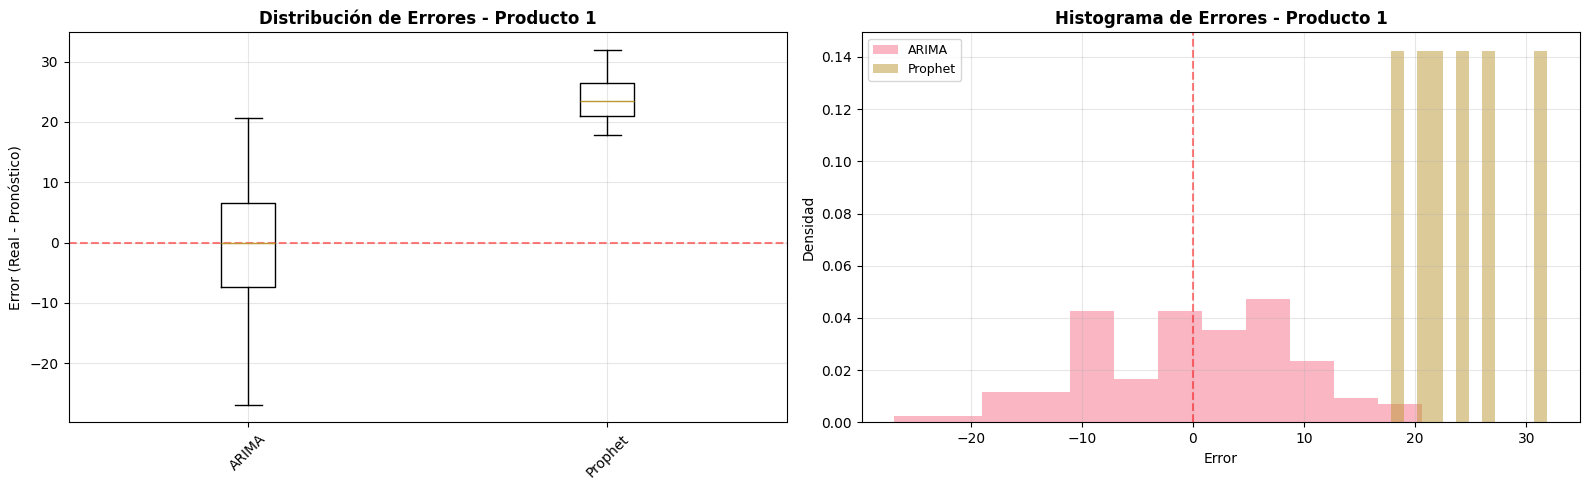

ESTADÍSTICAS DE ERRORES - PRODUCTO 1

ARIMA:
  Media: -0.1872
  Mediana: -0.0605
  Desv. Est.: 9.1043
  Mínimo: -26.8661
  Máximo: 20.6414

Prophet:
  Media: 24.0401
  Mediana: 23.4064
  Desv. Est.: 4.5483
  Mínimo: 17.8438
  Máximo: 31.9010


In [27]:
# Análisis de errores para Producto 1
if datasets is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    errores_modelos = {}
    
    # Media Móvil
    if resultados['MA_HW'] is not None:
        try:
            mejor_ma = None
            mejor_rmse = float('inf')
            for ventana, datos in resultados['MA_HW']['producto1']['media_movil'].items():
                if datos['rmse'] < mejor_rmse:
                    mejor_rmse = datos['rmse']
                    mejor_ma = datos
            if mejor_ma is not None:
                errores_modelos['Media Móvil'] = mejor_ma['errores']
        except:
            pass
    
    # Holt-Winters
    if resultados['MA_HW'] is not None:
        try:
            hw_p1 = resultados['MA_HW']['producto1']['holt_winters']
            errores_modelos['Holt-Winters'] = hw_p1['errores']
        except:
            pass
    
    # Tendencias
    if resultados['Tendencias'] is not None:
        try:
            tend_p1 = resultados['Tendencias']['producto1']
            errores_modelos['Tendencia Pol.'] = tend_p1['errores_mejor']
        except:
            pass
    
    # ARIMA
    if resultados['ARIMA'] is not None:
        try:
            errores_modelos['ARIMA'] = resultados['ARIMA']['producto1']['errores_rolling_opt']
        except:
            pass
    
    # Prophet
    if resultados['Prophet'] is not None:
        try:
            errores_modelos['Prophet'] = resultados['Prophet']['producto1']['errores_test']
        except:
            pass
    
    # Boxplot de errores
    if len(errores_modelos) > 0:
        axes[0].boxplot(errores_modelos.values(), labels=errores_modelos.keys())
        axes[0].set_title('Distribución de Errores - Producto 1', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Error (Real - Pronóstico)')
        axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
        axes[0].grid(True, alpha=0.3)
        axes[0].tick_params(axis='x', rotation=45)
        
        # Histograma de errores
        for modelo, errores in errores_modelos.items():
            axes[1].hist(errores, alpha=0.5, bins=12, label=modelo, density=True)
        
        axes[1].set_title('Histograma de Errores - Producto 1', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Error')
        axes[1].set_ylabel('Densidad')
        axes[1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas de errores
    print('='*70)
    print('ESTADÍSTICAS DE ERRORES - PRODUCTO 1')
    print('='*70)
    for modelo, errores in errores_modelos.items():
        print(f"\n{modelo}:")
        print(f"  Media: {np.mean(errores):.4f}")
        print(f"  Mediana: {np.median(errores):.4f}")
        print(f"  Desv. Est.: {np.std(errores):.4f}")
        print(f"  Mínimo: {np.min(errores):.4f}")
        print(f"  Máximo: {np.max(errores):.4f}")
    print('='*70)

## 8. TABLA RESUMEN FINAL

In [28]:
# Crear tabla resumen completa
print('='*80)
print('RESUMEN FINAL - COMPARACIÓN DE MODELOS')
print('='*80)

print('\n--- PRODUCTO 1 ---')
print(df_metricas_p1[['Ranking', 'Modelo', 'Configuración', 'RMSE']].to_string(index=False))

if len(df_metricas_p2) > 0:
    print('\n--- PRODUCTO 2 ---')
    print(df_metricas_p2[['Ranking', 'Modelo', 'Configuración', 'RMSE']].to_string(index=False))

print('\n' + '='*80)
print('RECOMENDACIONES FINALES')
print('='*80)

print(f"\nPRODUCTO 1:")
print(f"  Modelo recomendado: {mejor_modelo_p1['Modelo']}")
print(f"  Configuración: {mejor_modelo_p1['Configuración']}")
print(f"  RMSE: {mejor_modelo_p1['RMSE']:.4f}")

if len(df_metricas_p2) > 0:
    print(f"\nPRODUCTO 2:")
    print(f"  Modelo recomendado: {mejor_modelo_p2['Modelo']}")
    print(f"  Configuración: {mejor_modelo_p2['Configuración']}")
    print(f"  RMSE: {mejor_modelo_p2['RMSE']:.4f}")

print('\n' + '='*80)

RESUMEN FINAL - COMPARACIÓN DE MODELOS

--- PRODUCTO 1 ---
 Ranking  Modelo      Configuración      RMSE
       1   ARIMA     ARIMA(6, 2, 7)  9.106204
       2 Prophet Prophet Optimizado 24.466578

--- PRODUCTO 2 ---
 Ranking Modelo  Configuración      RMSE
       1  ARIMA ARIMA(3, 1, 1) 12.598194

RECOMENDACIONES FINALES

PRODUCTO 1:
  Modelo recomendado: ARIMA
  Configuración: ARIMA(6, 2, 7)
  RMSE: 9.1062

PRODUCTO 2:
  Modelo recomendado: ARIMA
  Configuración: ARIMA(3, 1, 1)
  RMSE: 12.5982



## 9. GUARDAR COMPARACIÓN FINAL

In [29]:
# Guardar comparación final
comparacion_final = {
    'producto1': {
        'metricas': df_metricas_p1.to_dict('records'),
        'mejor_modelo': mejor_modelo_p1.to_dict()
    }
}

if len(df_metricas_p2) > 0:
    comparacion_final['producto2'] = {
        'metricas': df_metricas_p2.to_dict('records'),
        'mejor_modelo': mejor_modelo_p2.to_dict()
    }

with open('comparacion_final_modelos.pkl', 'wb') as f:
    pickle.dump(comparacion_final, f)

print('Comparación final guardada en comparacion_final_modelos.pkl')

Comparación final guardada en comparacion_final_modelos.pkl
